In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
import os
os.chdir('..')
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/final_data/final_dataset.csv')
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
df = df.sort_values(['SID', 'ISO_TIME']).reset_index(drop=True)

print(f'Dataset: {df.shape[0]:,} dòng | {df["SID"].nunique():,} cơn bão')
print(f'Giai đoạn: {df["YEAR"].min()} – {df["YEAR"].max()}')

Dataset: 40,838 dòng | 719 cơn bão
Giai đoạn: 2000 – 2025


1. Bản đồ quỹ đạo theo cấp cường độ (TD/TS/STS/TY)

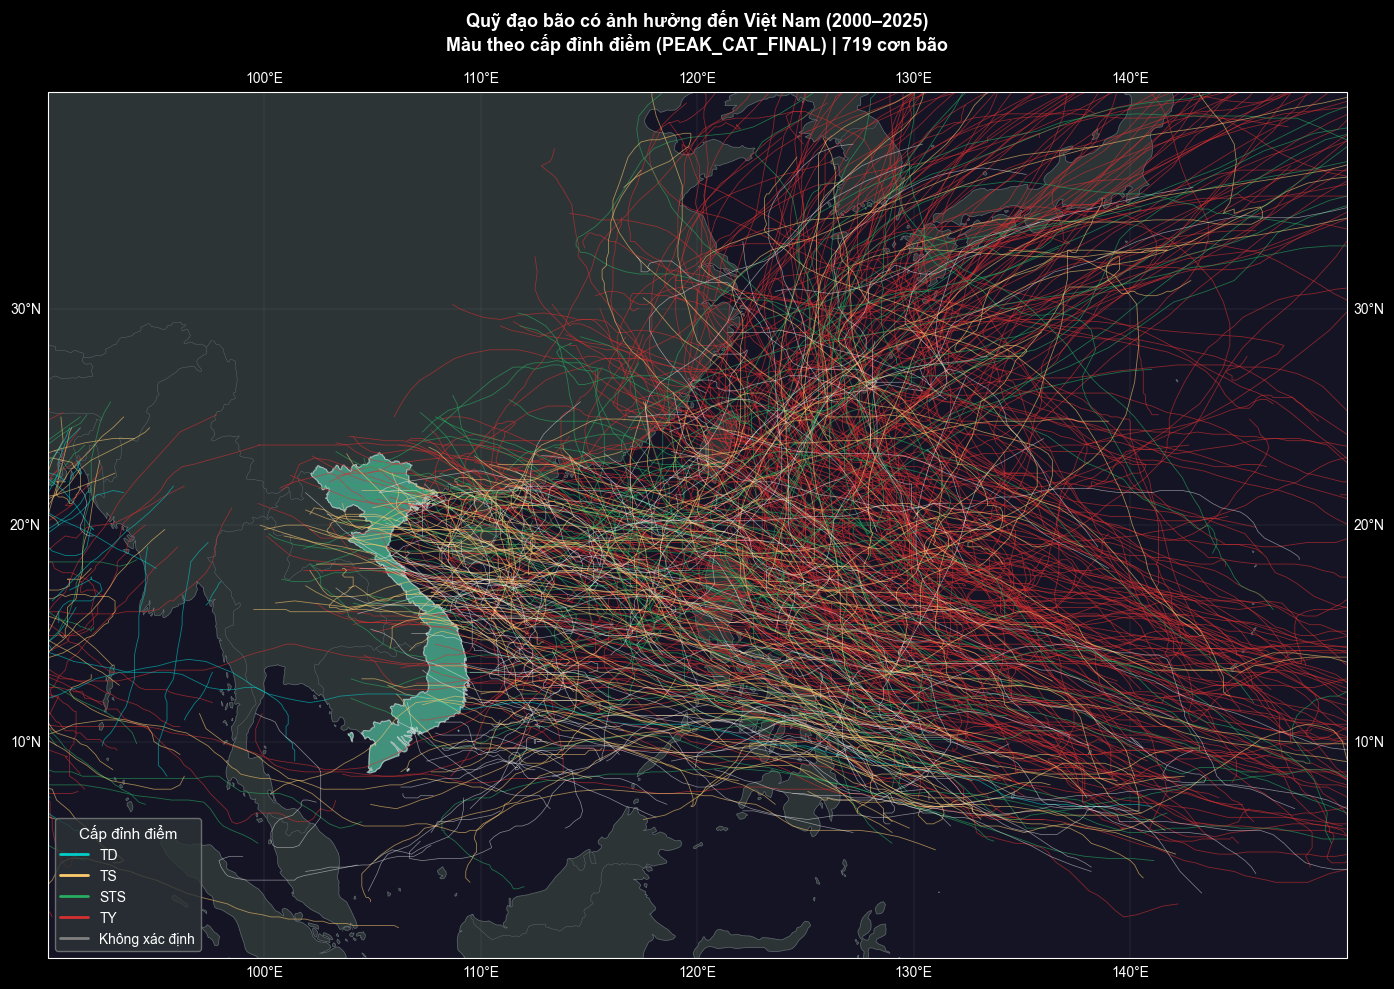

In [2]:
import cartopy.io.shapereader as shpreader

cat_order  = ['TD', 'TS', 'STS', 'TY']
cat_colors = {'TD': '#00cec9',   # xanh ngọc
              'TS': '#fdcb6e',   # vàng
              'STS': '#27ae60',  # xanh lá đậm
              'TY': '#d63031'}   # đỏ — nhiều nhất nhưng màu đỏ đặc trưng

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.PlateCarree(central_longitude=120))

# Phạm vi bản đồ
ax.set_extent([90, 150, 0, 40], crs=ccrs.PlateCarree())

# Nền bản đồ
ax.add_feature(cfeature.OCEAN, facecolor='#1a1a2e', alpha=0.8)
ax.add_feature(cfeature.LAND,  facecolor='#2d3436')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#636e72')
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='#636e72')
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4,
             xlocs=range(90, 155, 10), ylocs=range(0, 50, 10))

# Highlight Việt Nam
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
for country in reader.records():
    if country.attributes['NAME'] == 'Vietnam':
        ax.add_geometries([country.geometry],
                          ccrs.PlateCarree(),
                          facecolor='#55efc4',
                          edgecolor='white',
                          linewidth=0.8,
                          alpha=0.5)
        break

# Vẽ storms có cấp trước
for cat in ['TY', 'STS', 'TS', 'TD']:
    storms_cat = df[df['PEAK_CAT_FINAL'] == cat]['SID'].unique()
    for sid in storms_cat:
        group = df[df['SID'] == sid]
        ax.plot(group['LON'].values, group['LAT'].values,
                color=cat_colors[cat],
                linewidth=0.6, alpha=0.6,
                transform=ccrs.PlateCarree())

# Vẽ "không xác định" SAU CÙNG — đè lên trên
no_cat = df[df['PEAK_CAT_FINAL'].isna()]['SID'].unique()
for sid in no_cat:
    group = df[df['SID'] == sid]
    ax.plot(group['LON'].values, group['LAT'].values,
            color='white', linewidth=0.5, alpha=0.5,
            transform=ccrs.PlateCarree())

# Legend
legend_elements = [
    Line2D([0], [0], color=cat_colors[c], linewidth=2, label=c)
    for c in cat_order
]+ [Line2D([0], [0], color='gray', linewidth=2, label='Không xác định')]

ax.legend(handles=legend_elements, title='Cấp đỉnh điểm',
          loc='lower left', fontsize=10, title_fontsize=11,
          facecolor='#2d3436', labelcolor='white', edgecolor='gray')

ax.set_title(f'Quỹ đạo bão có ảnh hưởng đến Việt Nam (2000–2025)\n'
             f'Màu theo cấp đỉnh điểm (PEAK_CAT_FINAL) | {df["SID"].nunique()} cơn bão',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

Nhận xét:
- Trong giai đoạn 2000–2025, 719 cơn bão đi qua phạm vi 2000km quanh Việt Nam, trong đó TY chiếm tỉ lệ lớn nhất và có quỹ đạo trải rộng nhất.
- Phần lớn bão hình thành ở vùng biển phía Đông Philippines (120°–140°E, 5°–15°N) rồi di chuyển theo hướng Tây Bắc về phía Biển Đông và Việt Nam - đây là hành lang bão chủ đạo trong khu vực.
- TY và STS có xu hướng di chuyển lên vĩ độ cao hơn (25°–35°N) trước khi đổ bộ hoặc tan, trong khi TD và TS thường tan sớm ở vĩ độ thấp.
- 128 cơn bão không xác định cấp (trắng xám) phân bố rải rác, tập trung nhiều ở phía Tây và Nam - phù hợp với các storms hình thành gần bờ hoặc có thời gian tồn tại ngắn, không đủ dữ liệu quan trắc WMO.

Lưu ý: Dataset IBTrACS lọc các cơn bão có ít nhất 1 điểm quan trắc trong phạm vi 2000km quanh Việt Nam - do đó toàn bộ quỹ đạo của cơn bão đó được hiển thị, kể cả phần nằm ngoài phạm vi 2000km.

2. Bản đồ mật độ (heatmap)

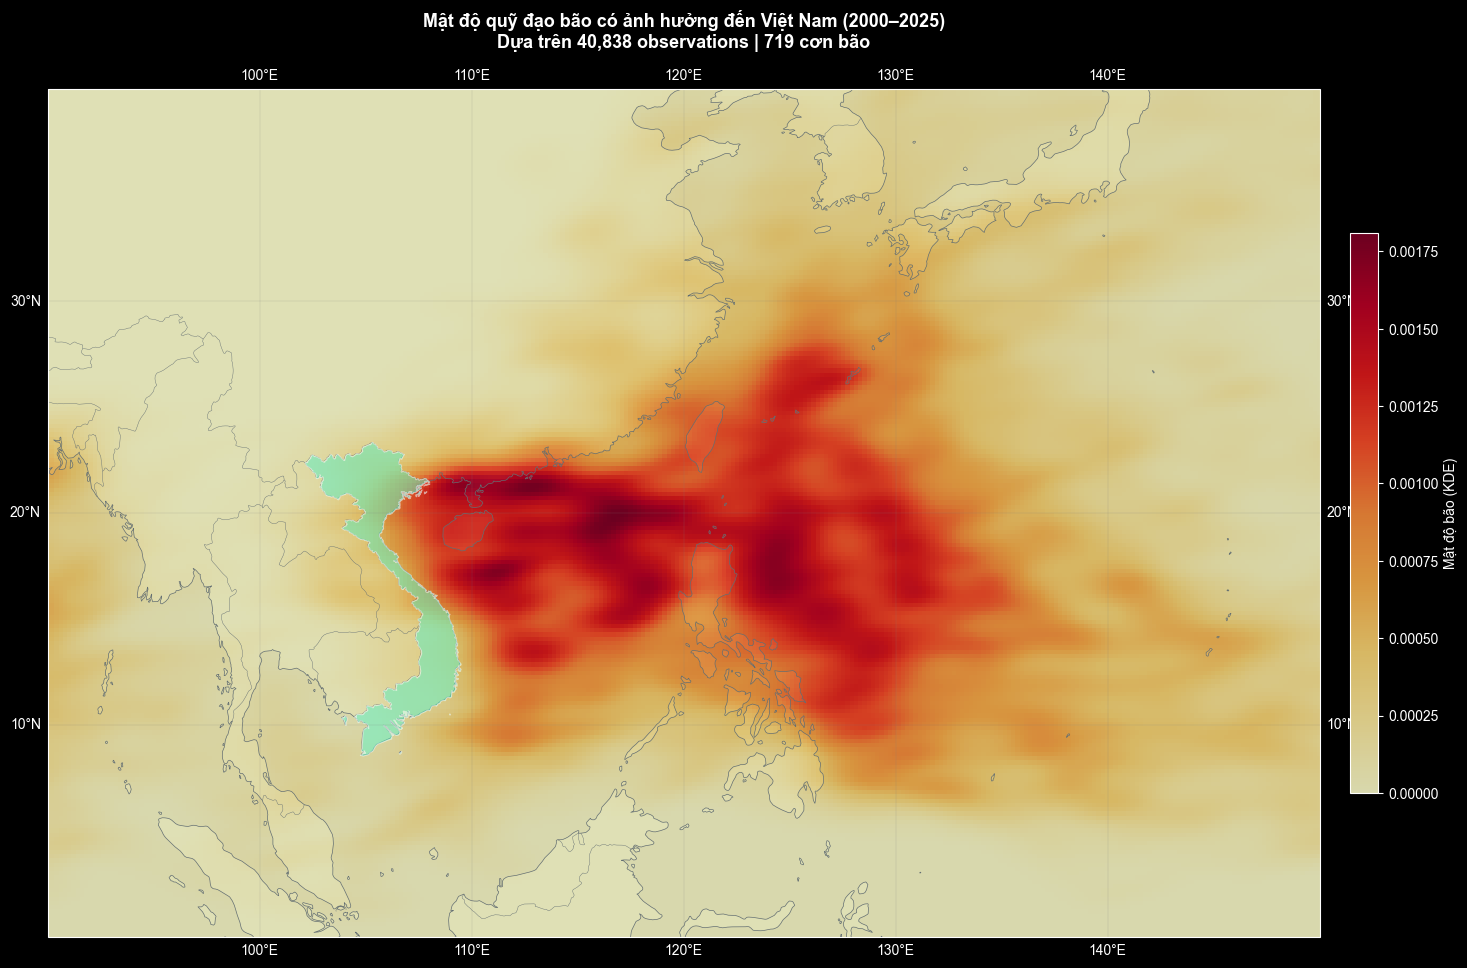

In [3]:
from scipy.stats import gaussian_kde

lons = df['LON'].dropna().values
lats = df['LAT'].dropna().values

# Tạo grid mịn
lon_grid = np.linspace(90, 150, 300)
lat_grid = np.linspace(0, 40, 200)
LON_GRID, LAT_GRID = np.meshgrid(lon_grid, lat_grid)

# KDE làm mịn
xy = np.vstack([lons, lats])
kde = gaussian_kde(xy, bw_method=0.05)
positions = np.vstack([LON_GRID.ravel(), LAT_GRID.ravel()])
density = kde(positions).reshape(LON_GRID.shape)

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.PlateCarree(central_longitude=120))
ax.set_extent([90, 150, 0, 40], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor='#2d3436')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#636e72')
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='#636e72')
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4,
             xlocs=range(90, 155, 10), ylocs=range(0, 45, 10))

# Highlight Việt Nam
for country in reader.records():
    if country.attributes['NAME'] == 'Vietnam':
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='#55efc4', edgecolor='white',
                          linewidth=0.8, alpha=0.5)
        break

pcm = ax.pcolormesh(LON_GRID, LAT_GRID, density,
                    cmap='YlOrRd', alpha=0.85,
                    transform=ccrs.PlateCarree())

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Mật độ bão (KDE)', fontsize=10)

ax.set_title(f'Mật độ quỹ đạo bão có ảnh hưởng đến Việt Nam (2000–2025)\n'
             f'Dựa trên {len(lons):,} observations | {df["SID"].nunique()} cơn bão',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

Nhận xét:
- Vùng có mật độ cao nhất (đỏ đậm) tập trung tại khu vực 110°–125°E, 15°–22°N (Biển Đông và vùng biển phía Đông Philippines). Đây là hành lang di chuyển chủ đạo của các cơn bão có ảnh hưởng đến Việt Nam trong giai đoạn 2000–2025.
- Khu vực Biển Đông tiếp giáp bờ biển miền Trung Việt Nam (110°–115°E, 15°–20°N) nằm trong vùng mật độ cao, cho thấy đây là khu vực các cơn bão thường xuyên đi qua với tần suất lớn trước khi ảnh hưởng trực tiếp đến miền Trung Việt Nam.
- Mật độ hoạt động giảm rõ rệt về phía Nam (dưới 10°N) và phía Bắc (trên 30°N), phù hợp với đặc trưng của bão nhiệt đới Tây Thái Bình Dương hoạt động mạnh nhất trong dải vĩ độ 10°–25°N.
- Mật độ trên đất liền thấp hơn đáng kể so với trên mặt biển, phản ánh đặc tính quỹ đạo của bão: chúng di chuyển chủ yếu trên biển để duy trì năng lượng trước khi đổ bộ vào đất liền.

3. Trực quan trên global 3D

In [4]:
import plotly.graph_objects as go

fig = go.Figure()

cat_colors = {
    'TD' : '#00cec9',
    'TS' : '#fdcb6e',
    'STS': '#00b894',
    'TY' : '#d63031',
    None : 'white'
}

# Vẽ từng track
for sid, group in df.groupby('SID'):
    group = group.sort_values('ISO_TIME')
    peak = group['PEAK_CAT_FINAL'].dropna()
    cat = peak.iloc[0] if not peak.empty else None
    color = cat_colors.get(cat, 'white')

    fig.add_trace(go.Scattergeo(
        lon=group['LON'].values,
        lat=group['LAT'].values,
        mode='lines',
        line=dict(width=1, color=color),
        opacity=0.6,
        showlegend=False,
        hoverinfo='skip'
    ))

# Highlight Việt Nam
fig.add_trace(go.Choropleth(
    locations=['VNM'],  # Mã ISO3 của Việt Nam
    z=[1],
    colorscale=[[0, '#55efc4'], [1, '#55efc4']],
    showscale=False,
    marker_line_color='white',
    marker_line_width=1,
    hoverinfo='skip'
))

# Layout quả cầu
fig.update_layout(
    geo=dict(
        projection_type='orthographic',
        projection=dict(
        type='orthographic',
        scale=1.2,
        rotation=dict(
            lon=115,  # xoay kinh độ về VN
            lat=15,   # xoay vĩ độ về VN
            roll=0)
        ),
        showland=True,
        landcolor='#2d3436',
        showocean=True,
        oceancolor='#1a1a2e',
        showcoastlines=True,
        coastlinecolor='#636e72',
        showcountries=True,
        countrycolor='#636e72',
        center=dict(lat=15, lon=115),  # VN ở giữa quả cầu
        bgcolor='black',
        showframe=False,
    ),
    paper_bgcolor='black',
    plot_bgcolor='black',
    margin=dict(l=0, r=0, t=40, b=0),
    height=800,  # ← tăng chiều cao
    title=dict(
        text='Quỹ đạo bão có ảnh hưởng đến Việt Nam (2000–2025)',
        font=dict(color='white', size=14)
    )
)

fig.write_html('output/08_track_globe.html')
print('Đã lưu: 08_track_globe.html')

Đã lưu: 08_track_globe.html
